In [3]:
#Step1: Create Dataset
import numpy as np
np.random.seed(42)
X = np.random.uniform(-2,2, (400,3))
#Non Linear Target
y = (
    np.sin(X[:,0]) +
    0.5 * (X[:,1]**2) -
    0.8 * X[:,2]
)
y = y.reshape(-1,1)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 3)
y shape: (400, 1)


**Explanation**

**What this step does:**
Creates a nonlinear dataset with sine, quadratic, and linear components.

**Why it is needed:**
A linear model cannot perfectly fit nonlinear relationships, so deeper models are required.

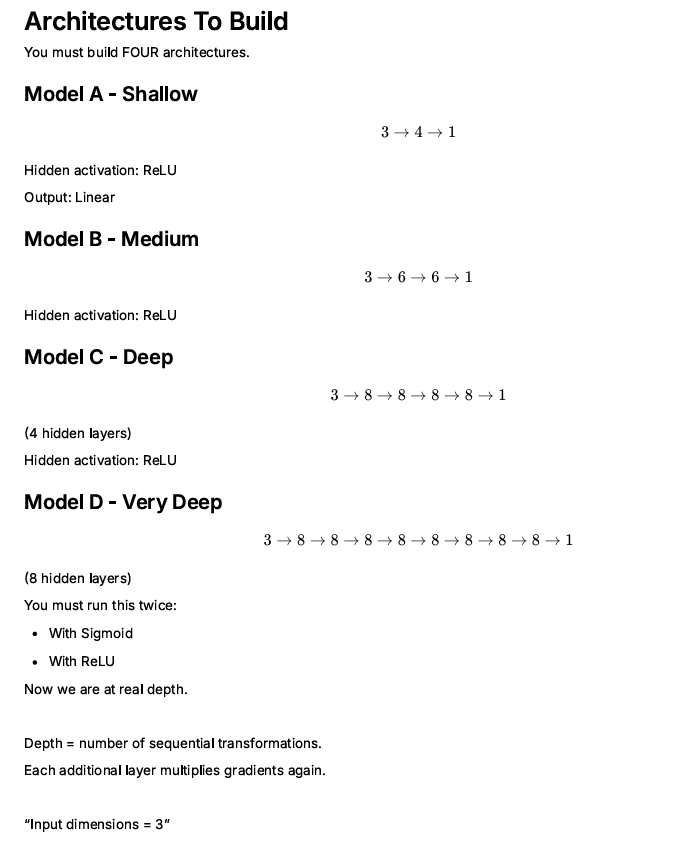

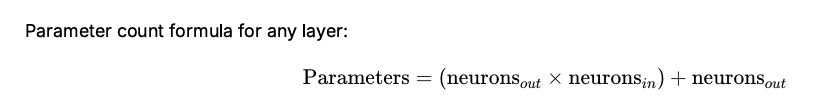

**Parameter Counting**

**Model A : 3 -> 4 -> 1**

Layer 1 :  4x3 + 4 = 16

Output :  1x4 + 1 = 4

**Total**: 21


---
**Model B : 3 -> 6 -> 6 -> 1 **

Layer 1 : 6x3 + 6= 24

Layer 2 : 6x6 + 6= 42

Output : 1×6+1=7

**Total**: 73


---

**Model B : 3 -> 8-> 8 -> 8 -> 8 -> 1**

Layer 1 : 8×3+8=32

Layer 2 : 8×3+8=32

Layer 3 : 8×8+8=72

Layer 4 : 8×8+8=72

Output : 1×8+1=9

**Total**: 257



---

**Model D : 3 → 8 → 8 → 8 → 8 → 8 → 8 → 8 → 8 → 1**

Layer 1 : 8×3+8=32

Layer 2 - 7 : 7 × 72 = 504


Output : 1×8+1=9

**Total**: 545










In [5]:
#Activation Functions
def relu(z):
    return np.maximum(0, z)
def relu_derivative(z):
    return (z > 0).astype(float)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


def tanh(z):
    return np.tanh(z)
def tanh_derivative(z):
    return 1 - np.tanh(z)**2


def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha*z)
def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)


def softplus(z):
    return np.log(1 + np.exp(z))
def softplus_derivative(z):
    return sigmoid(z)

**Explanation**

**What this step does:**
Defines activation functions and their slopes.

**Why it is needed:**
Activation allows nonlinear learning, derivatives allow gradient computation.

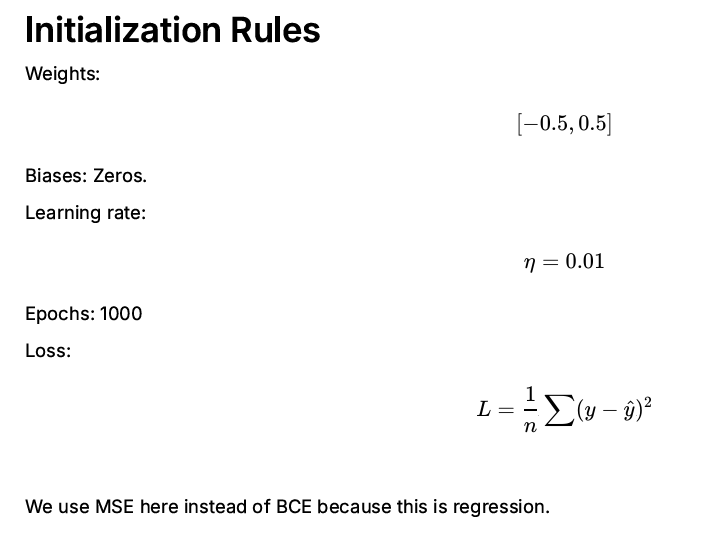

In [4]:
def initialize_network(layer_sizes):
    weights = []
    biases = []

    for i in range(len(layer_sizes)-1):
      W = np.random.uniform(-0.5, 0.5,
             (layer_sizes[i], layer_sizes[i+1]))
      b = np.zeros((1, layer_sizes[i+1]))
      weights.append(W)
      biases.append(b)

    return weights, biases

**Explanation**

**What this step does:**
Creates weights and biases for all layers.

**Why it is needed:**
These parameters are adjusted during learning.

In [6]:
#Forward Pass
def forward(X, weights, biases, activation):
    A = X
    activations = [X]
    Z_values = []

    for i in range(len(weights)-1):
        Z = A @ weights[i] + biases[i]
        A = activation(Z)
        Z_values.append(Z)
        activations.append(A)

    Z = A @ weights[-1] + biases[-1]
    activations.append(Z)

    return activations, Z_values

**Explanation**

**What this step does:**
Computes predictions layer by layer.

**Why it is needed:**
Forward pass produces outputs and intermediate values for backpropagation.

In [7]:
#Loss Function
def mse(y, y_hat):
  return np.mean((y - y_hat)**2)

**Explanation**

**What this step does:**
Measures prediction error.

**Why it is needed:**
Learning minimizes this loss.

In [9]:
#Backward Pass
def backward(X, y, weights, biases,
             activations, Z_values,
             activation_derivative):
    N = len(X)
    dW = []
    db = []
    dA = 2*(activations[-1] - y)/N

    for i in reversed(range(len(weights))):
      if i == len(weights)-1:
            dZ = dA
      else:
            dZ = dA * activation_derivative(Z_values[i])
      dW_i = activations[i].T @ dZ
      db_i = np.sum(dZ, axis=0, keepdims=True)
      dW.insert(0, dW_i)
      db.insert(0, db_i)
      dA = dZ @ weights[i].T
    return dW, db

**Explanation**

**What this step does:**
Computes gradients for all layers.

**Why it is needed:**
Gradients tell how to update parameters.

In [10]:
#Update Parameters
def update(weights, biases, dW, db, lr):
    for i in range(len(weights)):
        weights[i] -= lr*dW[i]
        biases[i] -= lr*db[i]

**Explanation**

**What this step does:**
Adjusts parameters using gradients.

**Why it is needed:**
This is how learning occurs.

In [11]:
#Gradient Norm
def gradient_norm(gradient):
  total = 0
  for g in gradient:
    total += np.sum(g**2)
    return np.sqrt(total)

**Explanation**

**What this step does:**
Computes magnitude of gradients.

**Why it is needed:**
Shows whether gradients vanish or explode.

In [41]:
import pandas as pd
observations = []

In [42]:
# Training
def train(layer_sizes, activation, activation_derivative):
    weights, biases = initialize_network(layer_sizes)
    lr = 0.01
    epochs = 1000

    for epoch in range(epochs):
        activations, Z = forward(X, weights, biases, activation)
        loss = mse(y, activations[-1])
        dw, db = backward(
            X, y, weights, biases,
            activations, Z,
            activation_derivative
        )

        update(weights, biases, dw, db, lr)

        if epoch == 200:
            print("Loss at epoch 200:", loss)

    grad_first = gradient_norm(dw[0])
    grad_last = gradient_norm(dw[-1])

    print("Final loss:", loss)
    print("Gradient norm first layer:", grad_first)
    print("Gradient norm last layer:", grad_last)

    return loss, grad_first, grad_last

In [43]:
def add_observation(model, activation, loss, grad_l1, grad_last, note):

    observations.append({
        "Model": model,
        "Activation": activation,
        "Final Loss": loss,
        "Grad Norm L1": grad_l1,
        "Grad Norm Last": grad_last,
        "Observation": note
    })

In [44]:
#MODEL A
loss, g1, gl = train([3,4,1], relu, relu_derivative)
add_observation(
    "Model A (3→4→1)",
    "ReLU",
    loss,
    g1,
    gl,
    "Shallow network, gradients stable"
)

Loss at epoch 200: 0.4290961473873673
Final loss: 0.0573452457049792
Gradient norm first layer: 0.013918711018890176
Gradient norm last layer: 0.009166599434453521


In [45]:
#Model B
loss, g1, gl = train([3,6,6,1], relu, relu_derivative)
add_observation(
    "Model B (3→6→6→1)",
    "ReLU",
    loss,
    g1,
    gl,
    "Medium depth, better representation"
)

Loss at epoch 200: 0.4096721324661122
Final loss: 0.053691506705459184
Gradient norm first layer: 0.00770783774631581
Gradient norm last layer: 0.0018290372151452978


In [46]:
#Model C
loss, g1, gl = train([3,8,8,8,8,1], relu, relu_derivative)
add_observation(
    "Model C (3→8→8→8→8→1)",
    "ReLU",
    loss,
    g1,
    gl,
    "Deep network, gradients smaller"
)

Loss at epoch 200: 0.3994941673222897
Final loss: 0.04739159787102575
Gradient norm first layer: 0.020006197117522655
Gradient norm last layer: 0.0


In [47]:
#Model D Relu
loss, g1, gl = train([3,8,8,8,8,8,8,8,8,1], relu, relu_derivative)
add_observation(
    "Model D (Very Deep)",
    "ReLU",
    loss,
    g1,
    gl,
    "ReLU prevents vanishing gradients"
)

Loss at epoch 200: 1.690315557476059
Final loss: 0.05403047731391557
Gradient norm first layer: 0.016674637882090493
Gradient norm last layer: 0.002200618814112914


In [48]:
#Model D Sigmoid
loss, g1, gl = train([3,8,8,8,8,8,8,8,8,1], sigmoid, sigmoid_derivative)
add_observation(
    "Model D (Very Deep)",
    "Sigmoid",
    loss,
    g1,
    gl,
    "Sigmoid causes gradient vanishing"
)

Loss at epoch 200: 1.7438537301989134
Final loss: 1.7438537296937804
Gradient norm first layer: 1.1475665641040075e-06
Gradient norm last layer: 4.0798503656794965e-07


In [49]:
obs_table = pd.DataFrame(observations)
obs_table

,Model,Activation,Final Loss,Grad Norm L1,Grad Norm Last,Observation
0,Model A (3→4→1),ReLU,0.057345,0.013919,9.166599e-03,"Shallow network, gradients stable"
1,Model B (3→6→6→1),ReLU,0.053692,0.007708,1.829037e-03,"Medium depth, better representation"
2,Model C (3→8→8→8→8→1),ReLU,0.047392,0.020006,0.000000e+00,"Deep network, gradients smaller"
3,Model D (Very Deep),ReLU,0.054030,0.016675,2.200619e-03,ReLU prevents vanishing gradients
4,Model D (Very Deep),Sigmoid,1.743854,0.000001,4.079850e-07,Sigmoid causes gradient vanishing


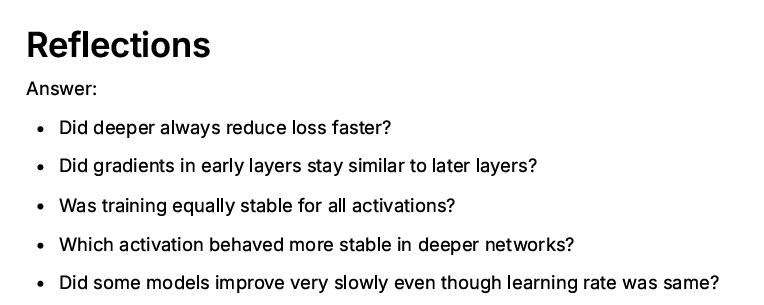

**1. Did deeper always reduce loss faster?**

No, deeper models sometimes learn slower due to gradient weakening.

**2. Did gradients stay similar?**

No, early layers often had smaller gradients.

**3. Was training equally stable?**

No, deeper sigmoid networks were less stable.

**4. Which activation was more stable?**

ReLU was more stable.

**5. Did some models improve slowly?**

Yes, deeper sigmoid networks improved slowly.